# Comparison with state-of-the-art

Best versions of MONSTER and LOBSTER vs state-of-the-art approaches 

- lock-based approach used in Tigon
- SWARM

We chose the best read retries for MONSTER and LOBSTER based on internal microbenchmark

- LOBSTER low contention: 1000
- LOBSTER high contention: 1
- MONSTER always: 10

We use perf. numbers corresponding to **10 read retries** unless stated otherwise.

We always use 9 processes unless stated otherwise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [64]:
plt.rcParams["font.family"] = "Linux Libertine"
# plt.rcParams["font.serif"] = "Linux Libertine"
plt.rcParams["font.size"] = 11
plt.rcParams['text.usetex'] = False
plt.rcParams["font.weight"] = "normal"

## Data
p9999 is actually worst case p9999 across a set of clients which
technically is p9999899, we refer to it as worst-case p9999.



In [8]:
3920+4743

8663

In [13]:
ycsba[LABEL_LOBSTER]

{'tput': 517672, 'avglat': 1.845, 'p9999': 2160}

In [78]:
# 9 processes (low contention)
# ── series labels ──────────────────────────────────────────────────────────────
LABEL_LOBSTER    = "LOBSTER"
LABEL_MONSTER0  = "MONSTER-0"
LABEL_MONSTER50  = "MONSTER-50"
LABEL_LOCK = "Lock (Tigon)"
LABEL_SWARM = "SWARM"


ycsba = {
    LABEL_LOBSTER: {"tput": 517672, "avglat": 1.845, "p9999": 2160},
    LABEL_MONSTER0: {"tput": 303764, "avglat": 2.9, "p9999": 13},
    LABEL_MONSTER50: {"tput": 273754, "avglat": 3.58, "p9999": 15}, # round time: 1300
    LABEL_LOCK: {"tput": 222723, "avglat": 4.33, "p9999": 13.43},
    LABEL_SWARM: {"tput": 164000, "avglat": 4.7, "p9999": 21.900},
}

ycsba_single = {
    LABEL_LOBSTER: {"tput": 18307, "avglat": 60.5, "p9999": 2150},
    LABEL_MONSTER0: {"tput": 126000, "avglat": 8.1, "p9999": 441},
    LABEL_MONSTER50: {"tput": 131000, "avglat": 7.6, "p9999": 106}, # round time: 1300
    LABEL_LOCK: {"tput": 39251, "avglat": 32.4, "p9999": 727},
    LABEL_SWARM: {"tput": 105000, "avglat": 7.45, "p9999": 50.4},
}

ycsbb = {
    LABEL_LOBSTER: {"tput": 601161, "avglat": 1.42, "p9999": 6.8},
    LABEL_MONSTER0: {"tput": 572715, "avglat": 2.92, "p9999": 12.66},
    LABEL_MONSTER50: {"tput": 534201, "avglat": 4.13, "p9999": 19.75}, # round time: 1300
    LABEL_LOCK: {"tput": 210326, "avglat": 3.96, "p9999": 16.39},
    LABEL_SWARM: {"tput": 250000, "avglat": 4.11, "p9999": 20.6},
}

## Main throughput latency bar plot

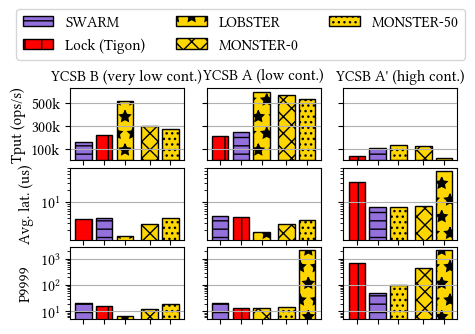

In [145]:
## global settings
colors = {
    LABEL_LOBSTER: "gold",
    LABEL_MONSTER0: "gold",
    LABEL_MONSTER50: "gold",
    LABEL_LOCK: "red",
    LABEL_SWARM: "mediumpurple" 
}

hatches = {
    LABEL_LOBSTER: "*",
    LABEL_MONSTER0: 'xx',
    LABEL_MONSTER50: "...",
    LABEL_LOCK: "|",
    LABEL_SWARM: "--" 
}

width   = 0.5
x = [1,2,3,4.2,5.2]
title_fontsize=11
fig, axs = plt.subplots(3, 3, figsize=(5, 3), gridspec_kw={"hspace": 0.1}, sharex="col", sharey="row")


## common barplot settings
def barplot(row, col, workload, metric, order):
    # x = [1,2,3,5,6]
    ax = axs[row][col]
    ax.grid(axis="y")
    heights = [workload[label][metric] for label in order]
    colors_ordered = [colors[label] for label in order]
    hatches_ordered = [hatches[label] for label in order]
    ax.bar(x, heights, ec='black', hatch=hatches_ordered, color=colors_ordered, label=order)

# tput
axs[0][0].set_yticks(
        [100_000, 300_000, 500_000],
        labels=["100k", "300k", "500k"],
    )
axs[0][0].set_ylabel("Tput (ops/s)")

metric = "tput"

axs[0][0].set_title("YCSB B (very low cont.)", fontsize=title_fontsize)
order = [LABEL_LOCK, LABEL_SWARM, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(0,1,ycsbb,metric,order)

axs[0][1].set_title("YCSB A (low cont.)", fontsize=title_fontsize)
order = [LABEL_SWARM, LABEL_LOCK, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(0,0,ycsba,metric,order)

axs[0][2].set_title("YCSB A' (high cont.)", fontsize=title_fontsize)
order = [LABEL_LOCK, LABEL_SWARM, LABEL_MONSTER50, LABEL_MONSTER0, LABEL_LOBSTER]
barplot(0,2,ycsba_single,metric,order)


# latency (row 1)
axs[1][0].set_yscale("log")
axs[1][0].set_ylabel("Avg. lat. (us)")

metric = "avglat"


order = [LABEL_LOCK, LABEL_SWARM, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(1,0,ycsbb,metric,order)

order = [LABEL_SWARM, LABEL_LOCK, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(1,1,ycsba,metric,order)

order = [LABEL_LOCK, LABEL_SWARM, LABEL_MONSTER50, LABEL_MONSTER0, LABEL_LOBSTER]
barplot(1,2,ycsba_single,metric,order)

# p9999 latency (row 2)
axs[2][0].set_yscale("log")
axs[2][0].set_ylabel("P9999")
axs[2][0].set_xticks(x,labels=[])
axs[2][1].set_xticks(x,labels=[])
axs[2][2].set_xticks(x,labels=[])
metric = "p9999"

order = [LABEL_SWARM, LABEL_LOCK, LABEL_LOBSTER, LABEL_MONSTER0, LABEL_MONSTER50]
barplot(2,0,ycsbb,metric,order)

order = [LABEL_SWARM, LABEL_LOCK, LABEL_MONSTER0, LABEL_MONSTER50, LABEL_LOBSTER]
barplot(2,1,ycsba,metric,order)


order = [LABEL_LOCK, LABEL_SWARM, LABEL_MONSTER50, LABEL_MONSTER0, LABEL_LOBSTER]
barplot(2,2,ycsba_single,metric,order)

# legend
axs[0][0].legend(loc="upper center", bbox_to_anchor=(1.5, 2.2), ncols=3,)


In [146]:
fig.savefig("barplot_comparison.pdf",bbox_inches = "tight", dpi=150)

# Throughput scale
Maximum number of throughput achievable by the system as the number of clients increases.

- 3 memory nodes
- 10 read retries
- workload: YCSB A
- 64B

In [155]:
# ── series styles ──────────────────────────────────────────────────────────────
linestyles = {
    LABEL_LOBSTER: "-*",
    LABEL_MONSTER0: "--x",
    LABEL_MONSTER50: "-.",
    LABEL_LOCK: ":3",
    LABEL_SWARM: "--o" 
}

linecolors = {
    LABEL_LOBSTER: "tab:blue",
    LABEL_MONSTER0: "tab:orange",
    LABEL_MONSTER50: "tab:green",
    LABEL_LOCK: "red",
    LABEL_SWARM: "mediumpurple" 
}


In [156]:
num_of_clients = np.array([4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96])
abe_tput_avg = np.array([546062, 526652, 500023, 474240, 449536, 432529, 409675, 393462, 
                384002, 365792, 347056, 329120, 313401, 294271, 279083, 260001, 204117, 
                         188186, 168308, 155518, 143587])
abe_tput_total_Mops = num_of_clients * abe_tput_avg / 1_000_000

monster1300r_tput_avg = np.array([263015, 260025, 256233, 250955, 241714, 236316, 230709, 
                                 225870, 224414, 219263, 209480, 203697, 197392, 190755,
                                 184823, 172462, 86681, 78885, 64406, 50240, 45088])
monster1300r_tput_total_Mops = num_of_clients * monster1300r_tput_avg / 1_000_000

lock_noclients = np.array([4,8,12,20,28,36,44,48,56,64,72,80,88,96])
lock_tput_avg = np.array([225226, 223733, 222660, 210817, 197153, 
                          155133, 95229, 80573, 58576, 45432, 28467, 
                          21637, 18712, 16691])
lock_tput_total_Mops = lock_noclients * lock_tput_avg / 1_000_000 

lock_noclients = np.array([4,8,12,20,28,36,44,48,56,64])

swarm_tput_avg = [0,0, 138.75,

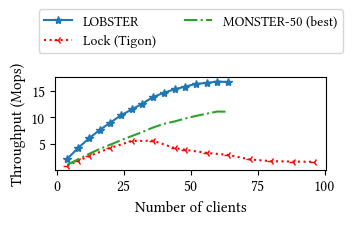

In [159]:
fig, axs = plt.subplots(1,1, figsize=(3.5, 1.2), sharey="all")

# plt.rcParams["font.size"] = 10

ax = axs
# ax.set_title("Client scalability", fontsize=11)
ax.set_xlabel("Number of clients")
ax.set_ylabel("Throughput (Mops)")
ax.plot(num_of_clients[:16], abe_tput_total_Mops[:16], linestyles[LABEL_LOBSTER], label=LABEL_LOBSTER)
ax.plot(lock_noclients[:16], lock_tput_total_Mops[:16], linestyles[LABEL_LOCK], label=LABEL_LOCK, color=linecolors[LABEL_LOCK])
ax.plot(num_of_clients[:16], monster1300r_tput_total_Mops[:16], linestyles[LABEL_MONSTER50], label="MONSTER-50 (best)",  color=linecolors[LABEL_MONSTER50])

ax.legend(loc="center", bbox_to_anchor=(0.5,1.5), ncols=2, fontsize=10)



In [144]:
fig.savefig("client_scale.pdf",bbox_inches = "tight", dpi=150)

## Memory node scale

Scaling the number of nodes for YCSB A workload. The number of nodes impacts the write operations in monster and abe since reads have the first-last-only optimization. 

- read retries: 10
- num of processes: 9

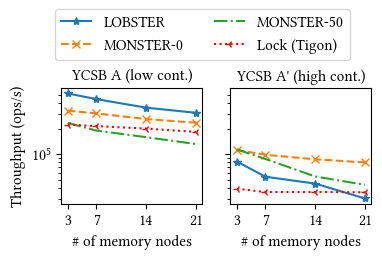

In [170]:
fig, axs = plt.subplots(1,2,figsize=(4, 1.5), sharey="all")

title_fontsize=11
mnodes = [3,7,14,21]

ax = axs[0]
abe_tput= [517672, 444434, 352620, 306652]
monsterasync_tput = [325026, 301641, 258823, 234177]
monstersync_tput = [233451, 189537, 158530, 131540]
lock_tput = [222723, 214223, 199820, 182842]

ax.set_title("YCSB A (low cont.)", fontsize=title_fontsize)
ax.plot(mnodes, abe_tput, linestyles[LABEL_LOBSTER], label=LABEL_LOBSTER)
ax.plot(mnodes, monsterasync_tput, linestyles[LABEL_MONSTER0], label=LABEL_MONSTER0)
ax.plot(mnodes, monstersync_tput, linestyles[LABEL_MONSTER50], label=LABEL_MONSTER50)
ax.plot(mnodes, lock_tput, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.set_xticks(mnodes)
ax.set_xlabel("# of memory nodes")
ax.set_ylabel("Throughput (ops/s)")
ax.set_yticks([100_000, 300_000, 500_000], labels=["100k", "300k", "500k"])

ax = axs[1]
abe_tput= [82000, 54285, 45098, 30139]
monsterasync_tput = [112000, 98375, 87000, 80000 ]
monstersync_tput = [ 113875, 87875, 54625, 43625 ]
lock_tput = [39251, 35871, 35871, 35661]

ax.set_title("YCSB A' (high cont.)",fontsize=title_fontsize)
ax.plot(mnodes, abe_tput, linestyles[LABEL_LOBSTER], label=LABEL_LOBSTER)
ax.plot(mnodes, monsterasync_tput, linestyles[LABEL_MONSTER0], label=LABEL_MONSTER0)
ax.plot(mnodes, monstersync_tput,  linestyles[LABEL_MONSTER50], label=LABEL_MONSTER50)
ax.plot(mnodes, lock_tput, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)

ax.set_xlabel("# of memory nodes")
ax.set_xticks(mnodes)
ax.set_yscale("log")
ax.legend(loc="upper center", bbox_to_anchor=(-0.2, 1.75),ncols=2)

# Object size

- 3 memory nodes
- 10 read retries
- Workload A
- 9 processes

In [129]:
obj_size = np.array([16, 128, 1024, 8192])

abe_tput_ops = np.array([556277, 464237, 203590, 53250])
abe_rlat = np.array([1.63, 1.94, 6.00, 17.50])
abe_wlat = np.array([1.22, 1.48, 2.40, 14.41])
abe_avglat = (abe_rlat + abe_wlat)/2
abe_tput_ops_cumulative = abe_tput_ops * 9
abe_tput_GiB = obj_size * abe_tput_ops_cumulative / 1024 / 1024 / 1024

monster10r_tput_ops = np.array([312286, 285378, 172316, 51422])
monster10r_rlat = np.array([1.37, 1.55, 4.21, 15.48])
monster10r_wlat = np.array([4.31, 4.58, 5.47, 17.88])
monster10r_avglat = (monster10r_rlat+monster10r_wlat)/2
monster10r_tput_ops_cumulative = monster10r_tput_ops * 9
monster10r_tput_GiB = obj_size * monster10r_tput_ops_cumulative / 1024 / 1024 / 1024

monster1300r_tput_ops = np.array([266992, 244075, 160275, 50263])
monster1300r_rlat = np.array([1.36, 1.55, 3.78, 14.97])
monster1300r_wlat = np.array([5.46, 5.83, 6.77, 19.38])
monster1300r_avglat = (monster1300r_rlat + monster1300r_wlat) /2 
monster1300r_tput_ops_cumulative = monster1300r_tput_ops * 9
monster1300r_tput_GiB = obj_size * monster1300r_tput_ops_cumulative / 1024 / 1024 / 1024

lock_tput_ops = np.array([225745, 214186, 161705, 62572])
lock_rlat = np.array([4.67, 4.78, 5.55, 11.08])
lock_wlat = np.array([3.24, 3.44, 4.67, 15.23])
lock_avglat = (lock_rlat + lock_wlat)/2
lock_tput_ops_cumulative = lock_tput_ops * 9
lock_tput_GiB = obj_size * lock_tput_ops_cumulative / 1024 / 1024 / 1024

########## YCSB B

b_abe_tput_ops = np.array([616651, 536264, 257953, 63461])
b_abe_rlat = np.array([1.41, 1.65, 3.64, 14.96])
b_abe_wlat = np.array([1.20, 1.42, 2.31, 14.48])
b_abe_avglat = (b_abe_rlat+b_abe_wlat)/2
b_abe_tput_ops_cumulative = b_abe_tput_ops * 9
b_abe_tput_GiB = obj_size * b_abe_tput_ops_cumulative / 1024 / 1024 / 1024

b_monster10r_tput_ops = np.array([579871, 520537, 249711, 65091])
b_monster10r_rlat = np.array([1.36, 1.54, 3.61, 14.34])
b_monster10r_wlat = np.array([4.21, 4.45, 5.39, 17.98])
b_monster10r_avglat = (b_monster10r_wlat + b_monster10r_rlat)/2
b_monster10r_tput_ops_cumulative = b_monster10r_tput_ops * 9
b_monster10r_tput_GiB = obj_size * b_monster10r_tput_ops_cumulative / 1024 / 1024 / 1024
98442
# b_monster1300r_tput_ops = np.array([266992, 244075, 160275, 50263])
# b_monster1300r_rlat = np.array([1.36, 1.55, 3.78, 14.97])
# b_monster1300r_wlat = np.array([5.46, 5.83, 6.77, 19.38])
# b_monster1300r_tput_ops_cumulative = monster1300r_tput_ops * 9
# b_monster1300r_tput_GiB = obj_size * monster1300r_tput_ops_cumulative / 1024 / 1024 / 1024

b_lock_tput_ops = np.array([212029, 207711, 185286, 98442])
b_lock_rlat = np.array([4.54, 4.62, 5.11, 9.24])
b_lock_wlat = np.array([3.26, 3.44, 4.57, 13.06])
b_lock_avglat = (b_lock_rlat + b_lock_wlat) / 2
b_lock_tput_ops_cumulative = b_lock_tput_ops * 9
b_lock_tput_GiB = obj_size * b_lock_tput_ops_cumulative / 1024 / 1024 / 1024

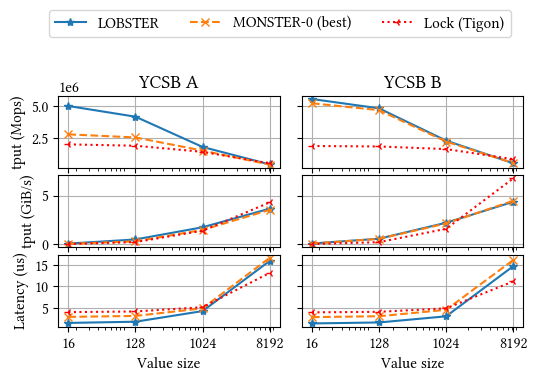

In [168]:
fig, axs = plt.subplots(3,2, figsize=(6,3), sharey="row", sharex="all", gridspec_kw={"wspace":0.1, "hspace":0.1})


ax = axs[0][0]
ax.set_title("YCSB A")
ax.grid()
ax.set_xscale("log")
ax.set_ylabel("tput (Mops)")

ax.plot(obj_size, abe_tput_ops_cumulative,  linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER)
ax.plot(obj_size, monster10r_tput_ops_cumulative,  linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)")
# ax.plot(obj_size, monster1300r_tput_ops_cumulative, STYLE_MONSTER_R)
ax.plot(obj_size, lock_tput_ops_cumulative, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)

ax = axs[1][0]
ax.grid()
ax.plot(obj_size, abe_tput_GiB, linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER)
ax.plot(obj_size, monster10r_tput_GiB,  linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)")
# ax.plot(obj_size, monster1300r_tput_GiB, STYLE_MONSTER_R)
ax.plot(obj_size, lock_tput_GiB, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
ax.set_ylabel("tput (GiB/s)")


ax = axs[2][0]
ax.grid()
ax.set_xlabel("Value size")
ax.set_xticks(obj_size,labels=obj_size)
ax.set_ylabel("Latency (us)")
# ax.plot(obj_size, abe_rlat, "-o", color="tab:blue", label="abe (read)")
ax.plot(obj_size, abe_avglat, linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER)
ax.plot(obj_size, monster10r_avglat,  linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)")
# ax.plot(obj_size, monster10r_wlat, "-x", color="tab:orange", label="monster async (write)")
# ax.plot(obj_size, monster1300r_avglat, STYLE_MONSTER_R, color="tab:green", label="MONSTER round-based")
# ax.plot(obj_size, monster1300r_wlat, "-x", color="tab:green", label="monster sync (write)")
ax.plot(obj_size, lock_avglat, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)
# ax.plot(obj_size, lock_wlat, "-x", color="magenta", label="lock (write)")




ax = axs[0][1]
ax.set_title("YCSB B")
ax.grid()

ax.plot(obj_size, b_abe_tput_ops_cumulative,  linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER)
ax.plot(obj_size, b_monster10r_tput_ops_cumulative, linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)")
ax.plot(obj_size, b_lock_tput_ops_cumulative, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)

ax = axs[1][1]
ax.grid()
ax.plot(obj_size, b_abe_tput_GiB, linestyles[LABEL_LOBSTER])
ax.plot(obj_size, b_monster10r_tput_GiB, linestyles[LABEL_MONSTER0])
ax.plot(obj_size, b_lock_tput_GiB,linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)

ax = axs[2][1]
ax.set_xlabel("Value size")
ax.grid()
ax.plot(obj_size, b_abe_avglat, linestyles[LABEL_LOBSTER], color=linecolors[LABEL_LOBSTER], label=LABEL_LOBSTER)
ax.plot(obj_size, b_monster10r_avglat, linestyles[LABEL_MONSTER0], color=linecolors[LABEL_MONSTER0], label="MONSTER-0 (best)")
ax.plot(obj_size, b_lock_avglat, linestyles[LABEL_LOCK], color=linecolors[LABEL_LOCK], label=LABEL_LOCK)



axs[2][0].legend(loc="center", bbox_to_anchor=(1,4.2), ncols=3)

